### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.over_sampling import BorderlineSMOTE, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from scipy import stats
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

### Load the Data

In [ ]:
# Load the uploaded label file
df = pd.read_csv("hscssp3_dr17_gc1_class_rs20231229.csv")

# Show structure of labels
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 687859 entries, 0 to 687858
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              687859 non-null  int64  
 1   id_sdss         687859 non-null  int64  
 2   ra              687859 non-null  float64
 3   dec             687859 non-null  float64
 4   skymap_id       687859 non-null  int64  
 5   sample          687859 non-null  str    
 6   z               687859 non-null  float64
 7   z_flag          687859 non-null  str    
 8   prob_sp         687859 non-null  float64
 9   prob_rg         687859 non-null  float64
 10  reduced_chisq   687859 non-null  float64
 11  mstar           687859 non-null  float64
 12  mstar_err68min  687859 non-null  float64
 13  mstar_err68max  687859 non-null  float64
 14  sfr             687859 non-null  float64
 15  sfr_err68min    687859 non-null  float64
 16  sfr_err68max    687859 non-null  float64
dtypes: float64(12), int64

In [ ]:
# make class from  'prob_sp'
def make_target(p):
    if p > 0.79:
        return "Spiral"
    elif p < 0.5:
        return "Non-Spiral"
    else:
        return "Intermediate"

df["target_class"] = df["prob_sp"].apply(make_target)

print("\nDistribusi target_class:")
print(df["target_class"].value_counts())

# Drop only identity

drop_cols = ["id", "id_sdss", "skymap_id", "ra", "dec"]
df_proportion = df["target_class"]
df_proportion.to_csv("data_gc_proportion.csv", index=False)
df = df.drop(columns=drop_cols)

print("\nKolom setelah drop ID:")
print(df.columns)

# One-hot encoding only for categorical columns

categorical_cols = ["sample", "z_flag"]

df = pd.get_dummies(df, columns=categorical_cols)

# Convert bool → int (0/1)
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print("\nKolom setelah OneHotEncoding:")
print(df.columns)
# Label encoding target

le = LabelEncoder()
df["target_class"] = le.fit_transform(df["target_class"])

print("\nMapping target_class:")
for i, cls in enumerate(le.classes_):
    print(f"{cls} → {i}")

# prob_sp used as a target, so it must be dropped
X = df.drop(columns=["target_class", "prob_sp"])
y = df["target_class"]
# Normalization

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Combine back with target
df_final = X_scaled.copy()
df_final["target_class"] = y.values

Dataset shape awal: (687859, 17)
                  id              id_sdss         ra       dec  skymap_id  \
0  36411435655366853  1237679438812610985  30.604164 -7.084937   82790002   
1  36411435655379508  1237679438812610641  30.578960 -7.080802   82790002   
2  36411435655380369  1237679438812610794  30.609513 -7.044947   82790002   
3  36411439950347843  1237679340030001416  30.611033 -6.962489   82790003   
4  36411439950348757  1237679340030001508  30.609168 -6.929949   82790003   

  sample         z z_flag   prob_sp   prob_rg  reduced_chisq         mstar  \
0    sub  0.203322   phot  0.770146  0.025958         2.7125  2.338000e+10   
1    sub  0.106500   phot  0.806715  0.024644         4.0000  1.442400e+10   
2    sub  0.181253   phot  0.903872  0.019853         2.4300  1.007800e+10   
3    sub  0.187636   phot  0.063089  0.096538        22.3725  9.370500e+10   
4    sub  0.076742   phot  0.299430  0.015849         0.0800  5.051100e+08   

   mstar_err68min  mstar_err68max  

In [ ]:
# Preparation data using df_final
# Split features and target from df_final
X = df_final.drop('target_class', axis=1)
y = df_final['target_class']

print("=" * 60)
print("Data before Resampling")
print("=" * 60)
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print("\nClass distribution before Resampling:")
print(y.value_counts().sort_index())
for cls in sorted(y.unique()):
    count = (y == cls).sum()
    print(f"  Class {cls}: {count} samples ({count/len(y)*100:.2f}%)")

# Calculate class weights from original distribution
classes = np.unique(y)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)
class_weight_dict = dict(zip(classes, class_weights))

print("\n" + "=" * 60)
print("Class Weights")
print("=" * 60)
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")

# Resampling with undersampling or oversampling, choose one 

# Undersampling
nearmiss = NearMiss(
   version=1,  
    n_neighbors=3
)
# Oversampling
# smote_tomek = SMOTETomek()

# X_resampled, y_resampled = smote_tomek.fit_resample(X, y)
X_resampled, y_resampled = nearmiss.fit_resample(X, y)

print("\n" + "=" * 60)
print("Data after Resampling")
print("=" * 60)
print(f"Shape X_resampled: {X_resampled.shape}")
print(f"Shape y_resampled: {y_resampled.shape}")
print("\nClass distribution after Resampling:")
unique, counts = np.unique(y_resampled, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} samples ({count/len(y_resampled)*100:.2f}%)")

# Convert to DataFrame for easier LDA later
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled_series = pd.Series(y_resampled, name='target_class')

# LDA (Dimensionality Reduction)

print("LDA")
lda = LinearDiscriminantAnalysis(
    n_components=2        # 3 classes → max 2
)

X_lda = lda.fit_transform(X_resampled, y_resampled)

print("\nDiscriminant Power:")
for i, ratio in enumerate(lda.explained_variance_ratio_):
    print(f" LD{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")


# Final Data

X_final = pd.DataFrame(X_lda, columns=['LD1','LD2'])
y_final = pd.Series(y_resampled)

print("\nFinal shape for FNN:", X_final.shape)

Data sebelum NearMiss
Shape X: (687859, 13)
Shape y: (687859,)

Distribusi kelas sebelum NearMiss:
target_class
0     57542
1    302203
2    328114
Name: count, dtype: int64
  Kelas 0: 57542 sampel (8.37%)
  Kelas 1: 302203 sampel (43.93%)
  Kelas 2: 328114 sampel (47.70%)

Class Weights
  Kelas 0: 3.9847
  Kelas 1: 0.7587
  Kelas 2: 0.6988

Data setelah NearMiss
Shape X_resampled: (172626, 13)
Shape y_resampled: (172626,)

Distribusi kelas setelah NearMiss:
  Kelas 0: 57542 sampel (33.33%)
  Kelas 1: 57542 sampel (33.33%)
  Kelas 2: 57542 sampel (33.33%)

------------------------------------------------------------
LINEAR DISCRIMINANT ANALYSIS
------------------------------------------------------------
Jumlah fitur asli     : 13
Jumlah komponen LDA   : 2

Discriminant Power:
 LD1: 0.9208 (92.08%)
 LD2: 0.0792 (7.92%)

Shape akhir untuk FNN: (172626, 2)


### Simulation

Train set      : 120838 samples (70.0%)
Validation set : 17245 samples (10.0%)
Test set       : 34543 samples (20.0%)
Total          : 172626 samples
Input features : 6

Indices - Train: 120838, Val: 17245, Test: 34543

MODEL ARCHITECTURE
FNNWithAttention(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (bn3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (attention): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (fc_out): Linear(in_features=16, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Total parameters: 3,476
T

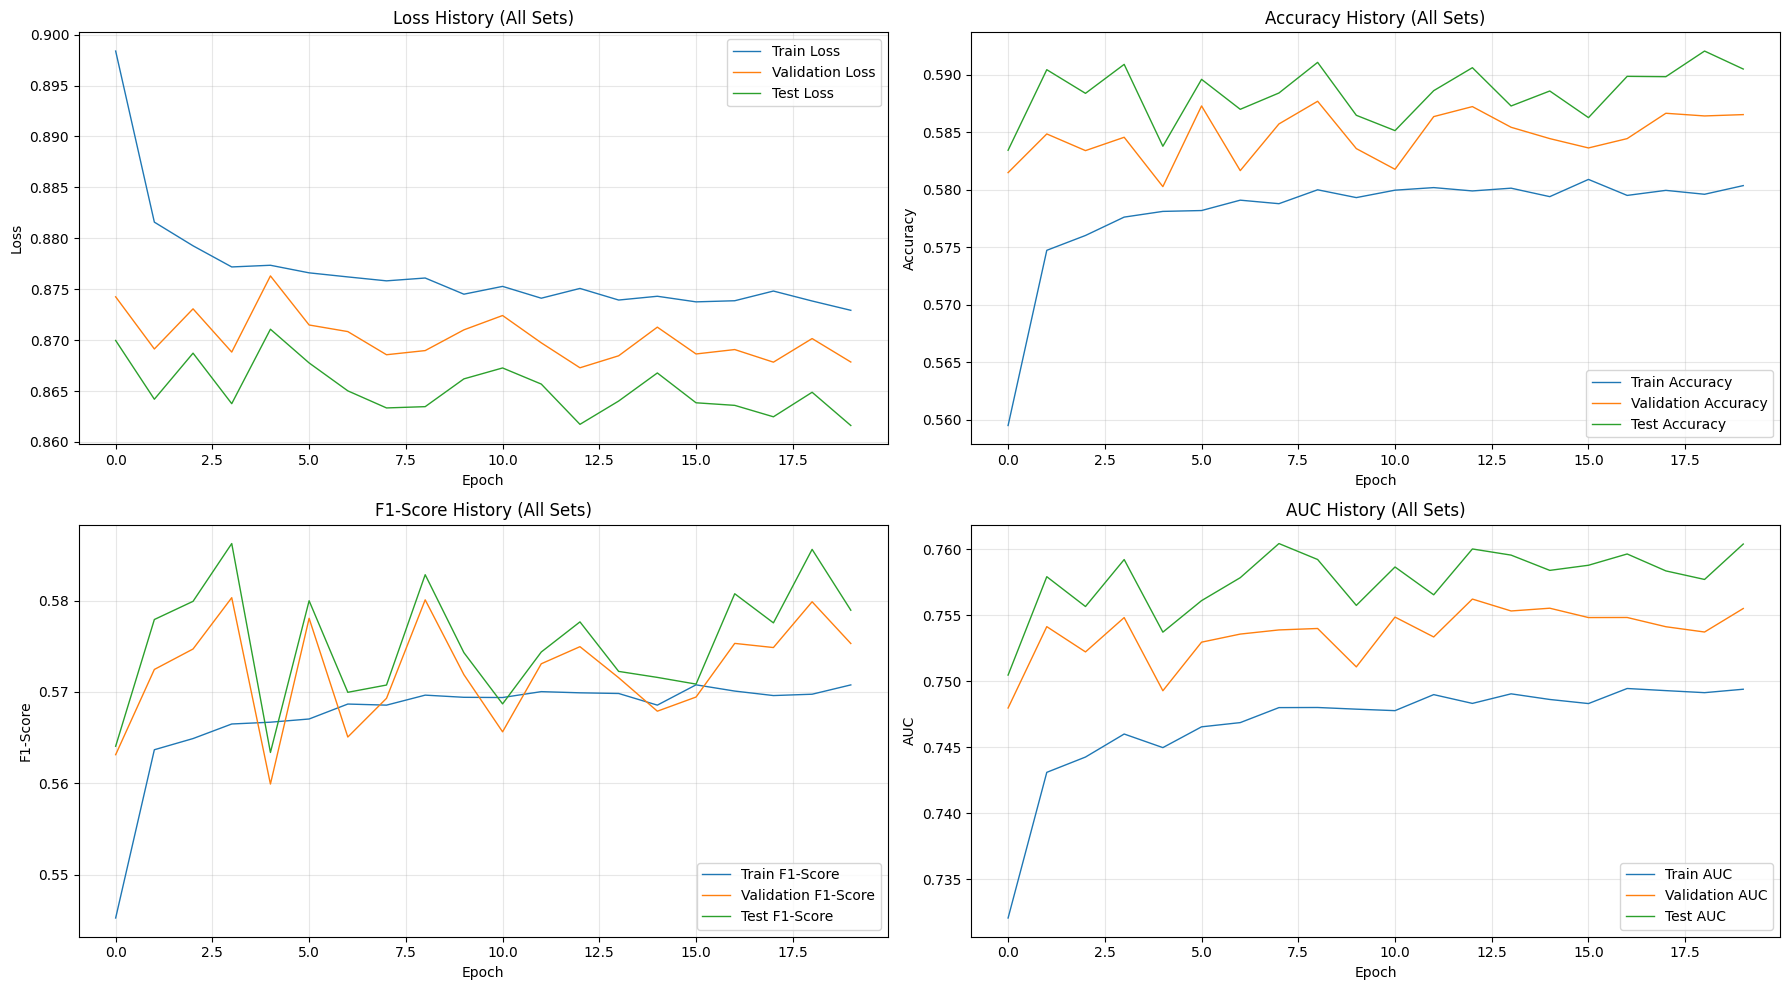


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

Intermediate       0.81      0.53      0.64     11514
  Non-Spiral       0.55      0.37      0.44     11515
      Spiral       0.52      0.87      0.65     11514

    accuracy                           0.59     34543
   macro avg       0.63      0.59      0.58     34543
weighted avg       0.63      0.59      0.58     34543



<Figure size 800x600 with 0 Axes>

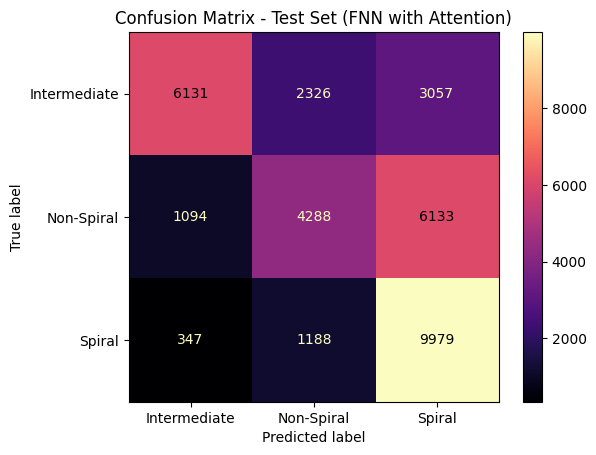


Shape X_test_lda: (34543, 2)
Shape y_test_array: (34543,)
Shape y_pred_array: (34543,)


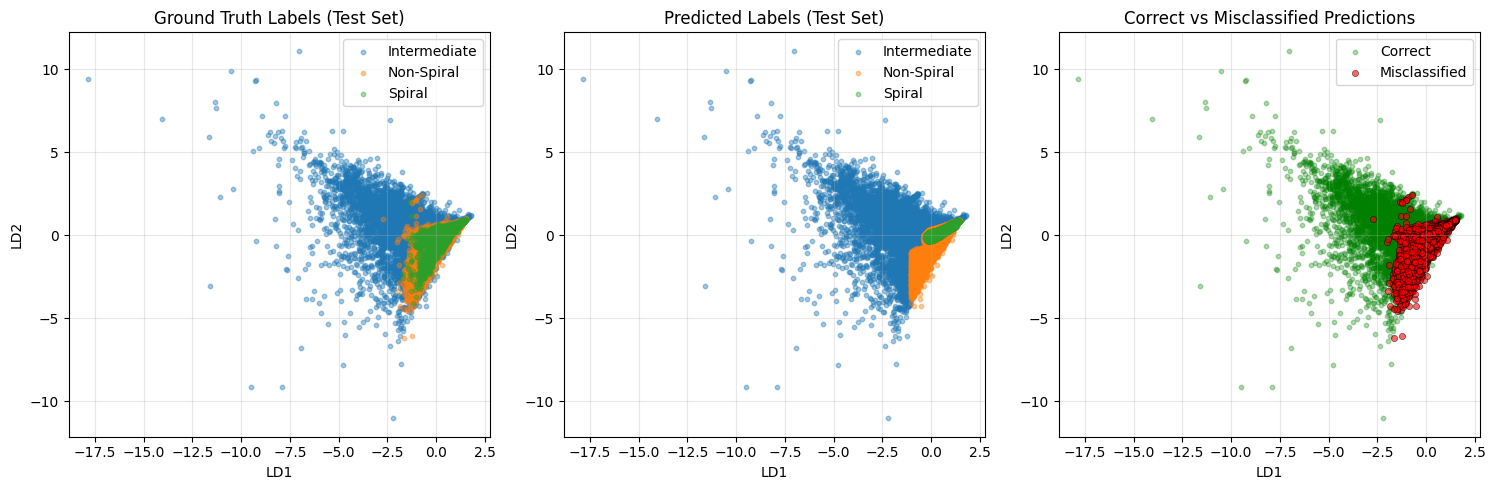

STATISTIK DETAIL
Train Loss         : 0.8729
Validation Loss    : 0.8679
Test Loss          : 0.8616
Train Accuracy     : 0.5804 (58.04%)
Train F1-Score     : 0.5708 (57.08%)
Validation Accuracy: 0.5865 (58.65%)
Validation F1-Score: 0.5753 (57.53%)
Best Validation F1 : 0.5803 (58.03%) at epoch 4
Test Accuracy      : 0.5905 (59.05%)
Test F1-Score      : 0.5790 (57.90%)
Test Precision     : 0.6266 (62.66%)
Test Recall        : 0.5905 (59.05%)
Train set      : 120838 samples (70.0%)
Validation set : 17245 samples (10.0%)
Test set       : 34543 samples (20.0%)
Total          : 172626 samples
Input features : 6

Indices - Train: 120838, Val: 17245, Test: 34543

MODEL ARCHITECTURE
FNNWithAttention(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

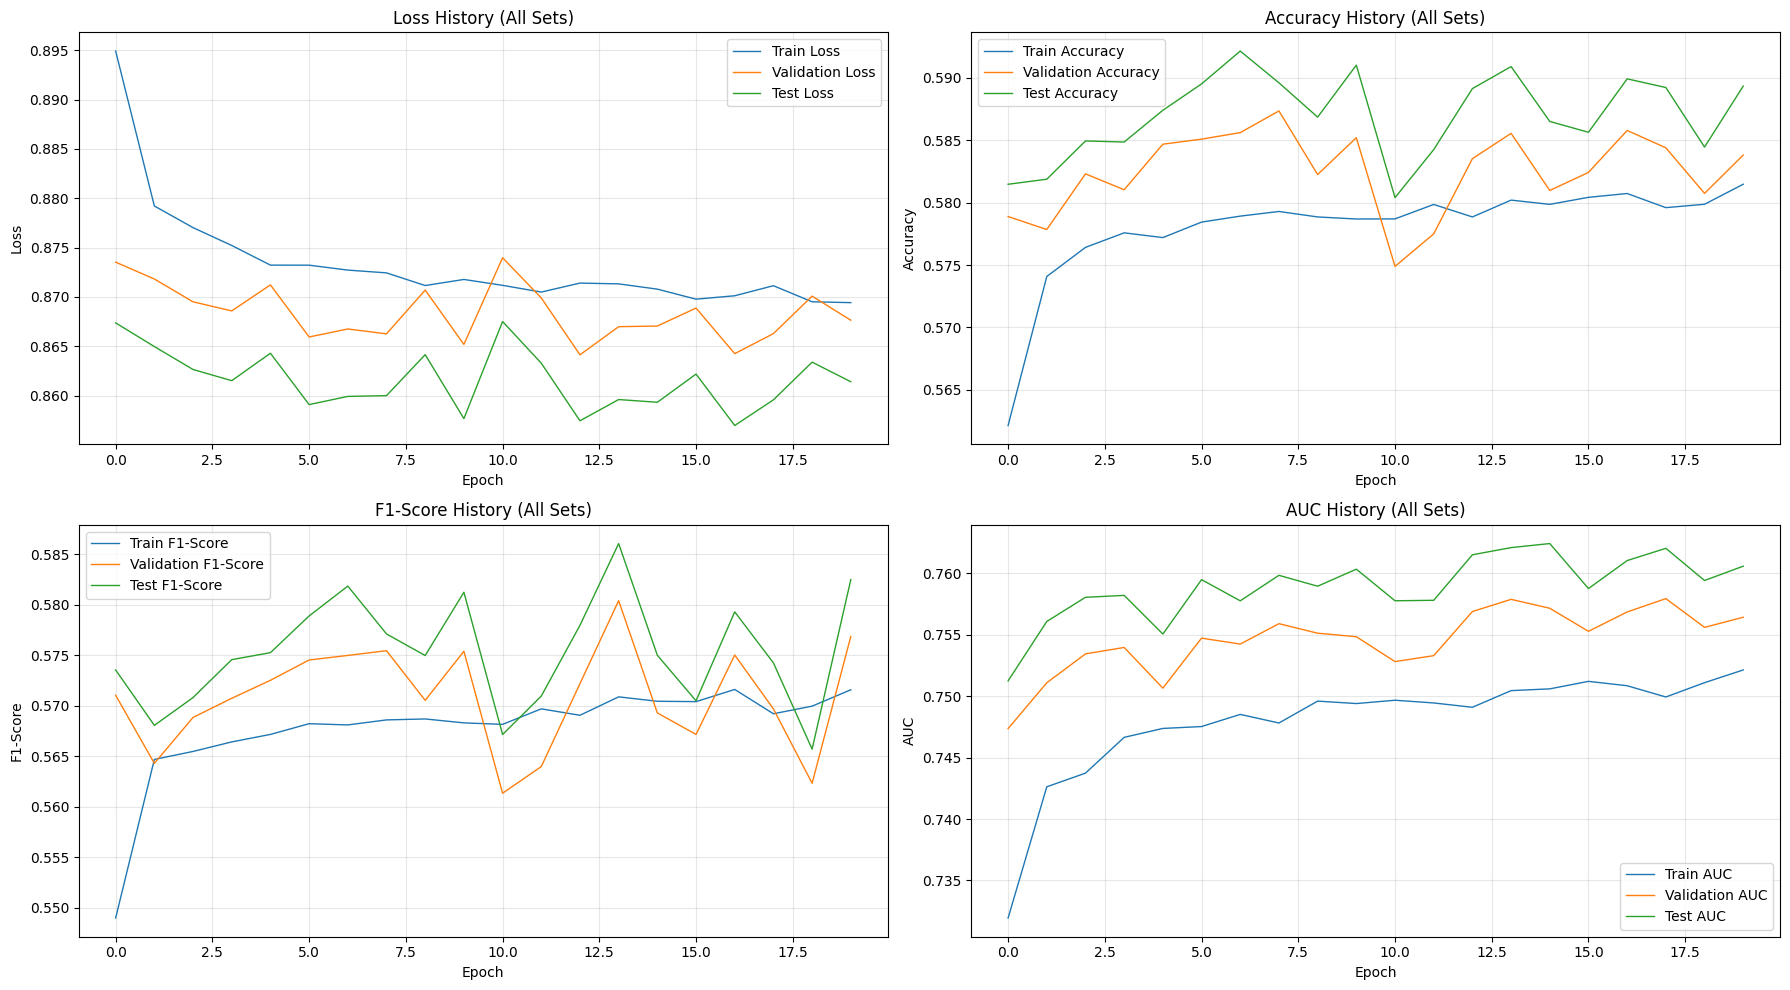


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

Intermediate       0.86      0.50      0.63     11514
  Non-Spiral       0.52      0.42      0.47     11515
      Spiral       0.53      0.84      0.65     11514

    accuracy                           0.59     34543
   macro avg       0.63      0.59      0.58     34543
weighted avg       0.63      0.59      0.58     34543



<Figure size 800x600 with 0 Axes>

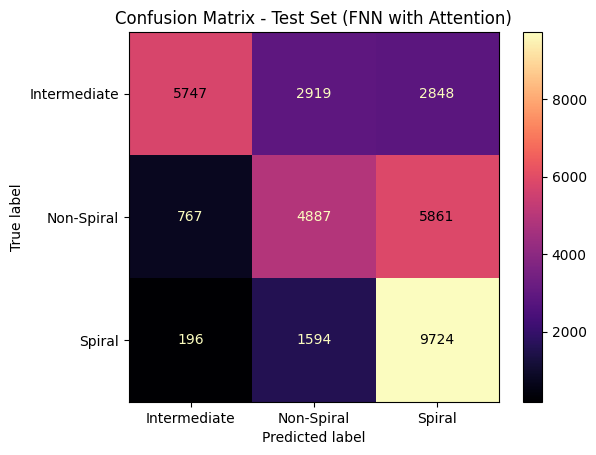


Shape X_test_lda: (34543, 2)
Shape y_test_array: (34543,)
Shape y_pred_array: (34543,)


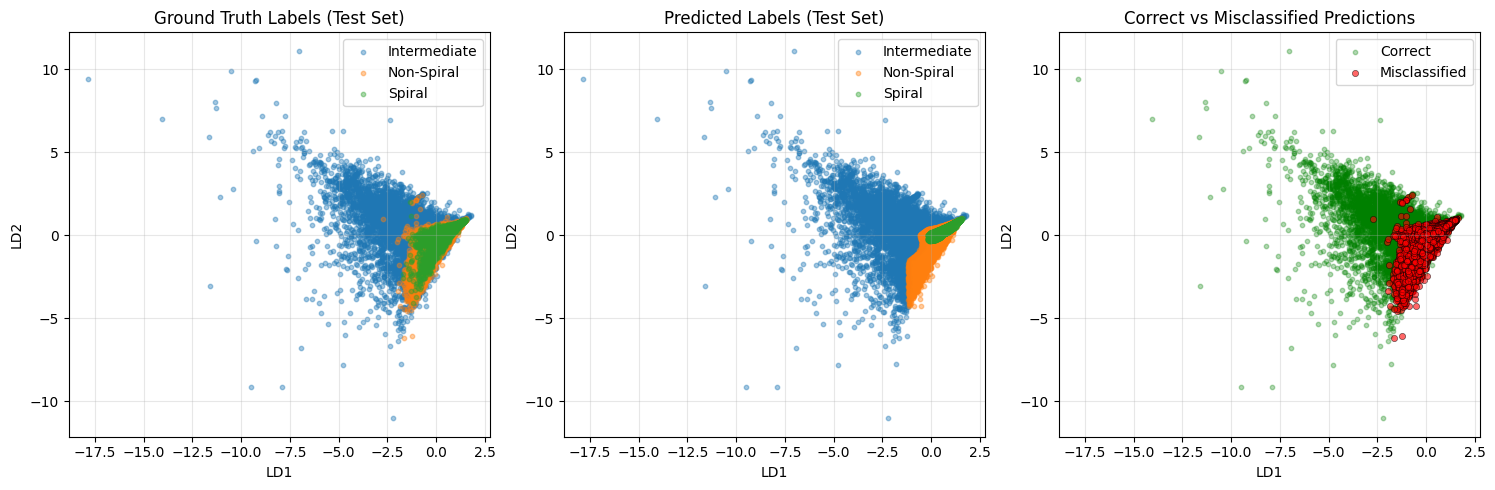

STATISTIK DETAIL
Train Loss         : 0.8694
Validation Loss    : 0.8676
Test Loss          : 0.8614
Train Accuracy     : 0.5815 (58.15%)
Train F1-Score     : 0.5716 (57.16%)
Validation Accuracy: 0.5838 (58.38%)
Validation F1-Score: 0.5769 (57.69%)
Best Validation F1 : 0.5804 (58.04%) at epoch 14
Test Accuracy      : 0.5894 (58.94%)
Test F1-Score      : 0.5825 (58.25%)
Test Precision     : 0.6346 (63.46%)
Test Recall        : 0.5894 (58.94%)
Train set      : 120838 samples (70.0%)
Validation set : 17245 samples (10.0%)
Test set       : 34543 samples (20.0%)
Total          : 172626 samples
Input features : 6

Indices - Train: 120838, Val: 17245, Test: 34543

MODEL ARCHITECTURE
FNNWithAttention(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


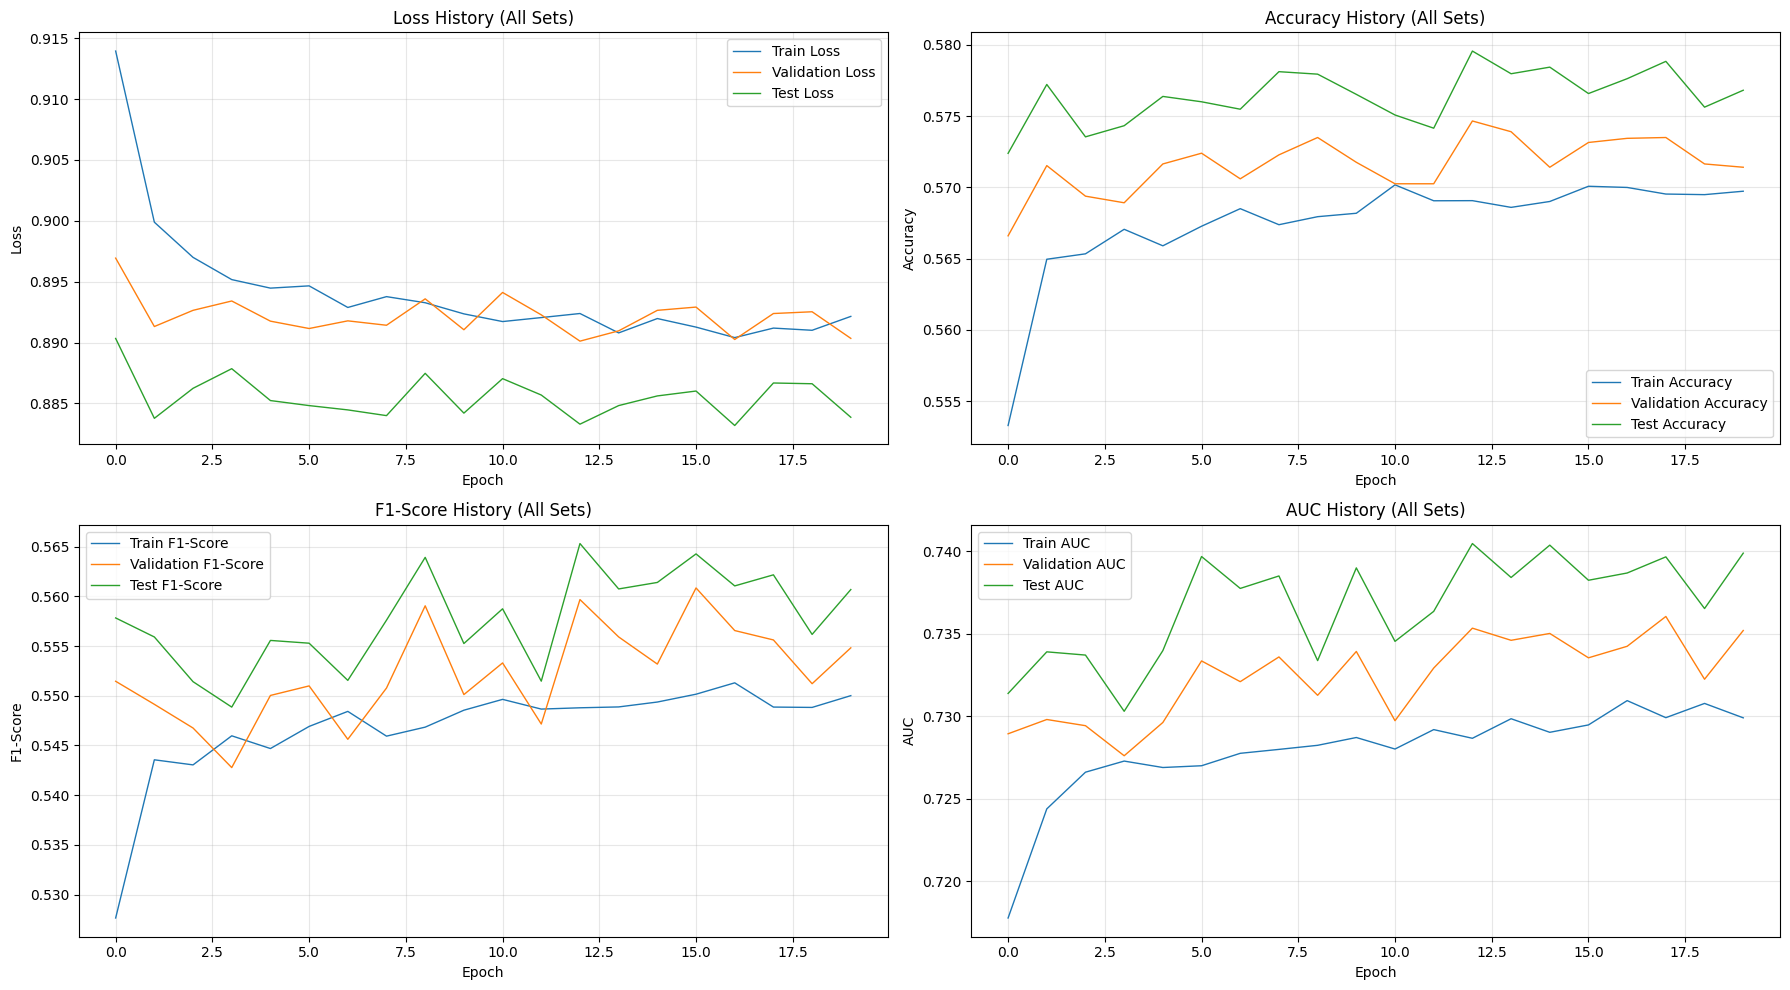


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

Intermediate       0.74      0.57      0.65     11514
  Non-Spiral       0.53      0.32      0.39     11515
      Spiral       0.52      0.84      0.64     11514

    accuracy                           0.58     34543
   macro avg       0.59      0.58      0.56     34543
weighted avg       0.59      0.58      0.56     34543



<Figure size 800x600 with 0 Axes>

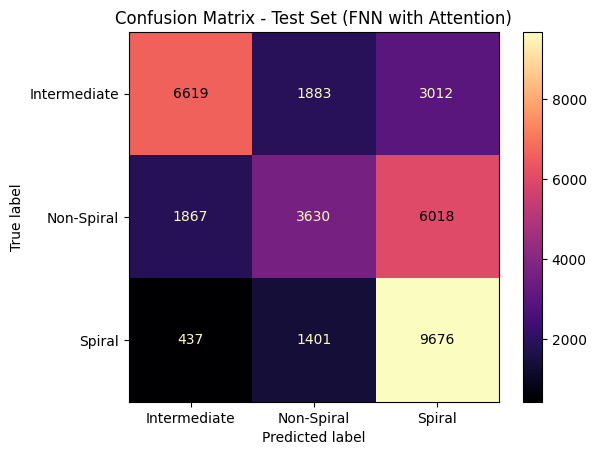


Shape X_test_lda: (34543, 2)
Shape y_test_array: (34543,)
Shape y_pred_array: (34543,)


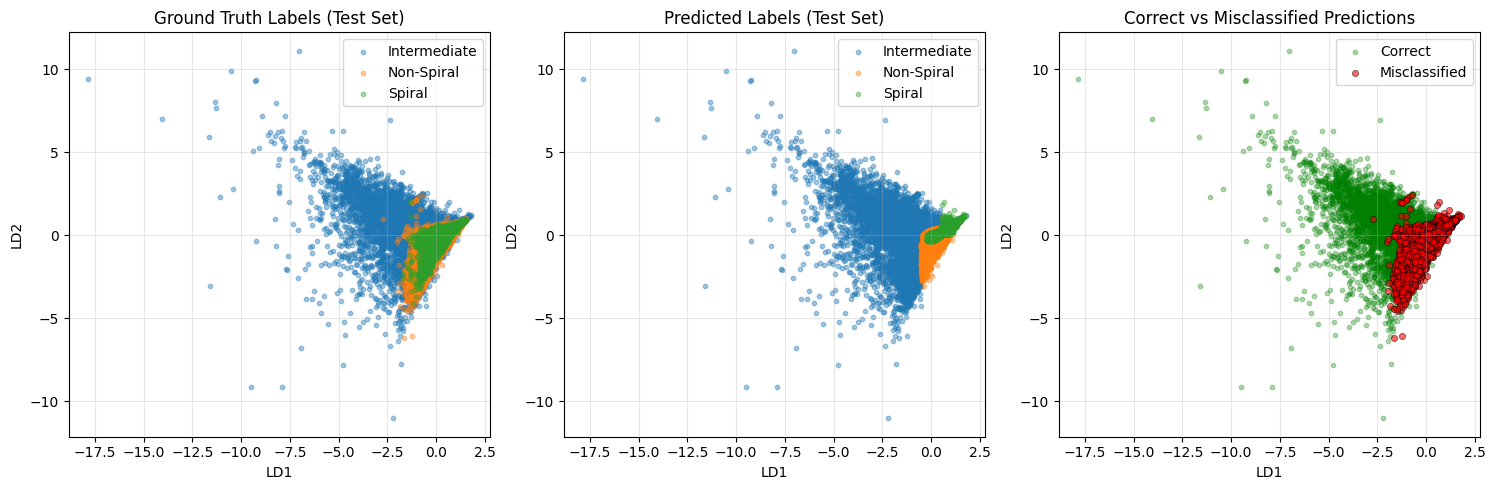

STATISTIK DETAIL
Train Loss         : 0.8921
Validation Loss    : 0.8903
Test Loss          : 0.8839
Train Accuracy     : 0.5697 (56.97%)
Train F1-Score     : 0.5500 (55.00%)
Validation Accuracy: 0.5714 (57.14%)
Validation F1-Score: 0.5548 (55.48%)
Best Validation F1 : 0.5608 (56.08%) at epoch 16
Test Accuracy      : 0.5768 (57.68%)
Test F1-Score      : 0.5607 (56.07%)
Test Precision     : 0.5947 (59.47%)
Test Recall        : 0.5768 (57.68%)
Train set      : 120838 samples (70.0%)
Validation set : 17245 samples (10.0%)
Test set       : 34543 samples (20.0%)
Total          : 172626 samples
Input features : 6

Indices - Train: 120838, Val: 17245, Test: 34543

MODEL ARCHITECTURE
FNNWithAttention(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


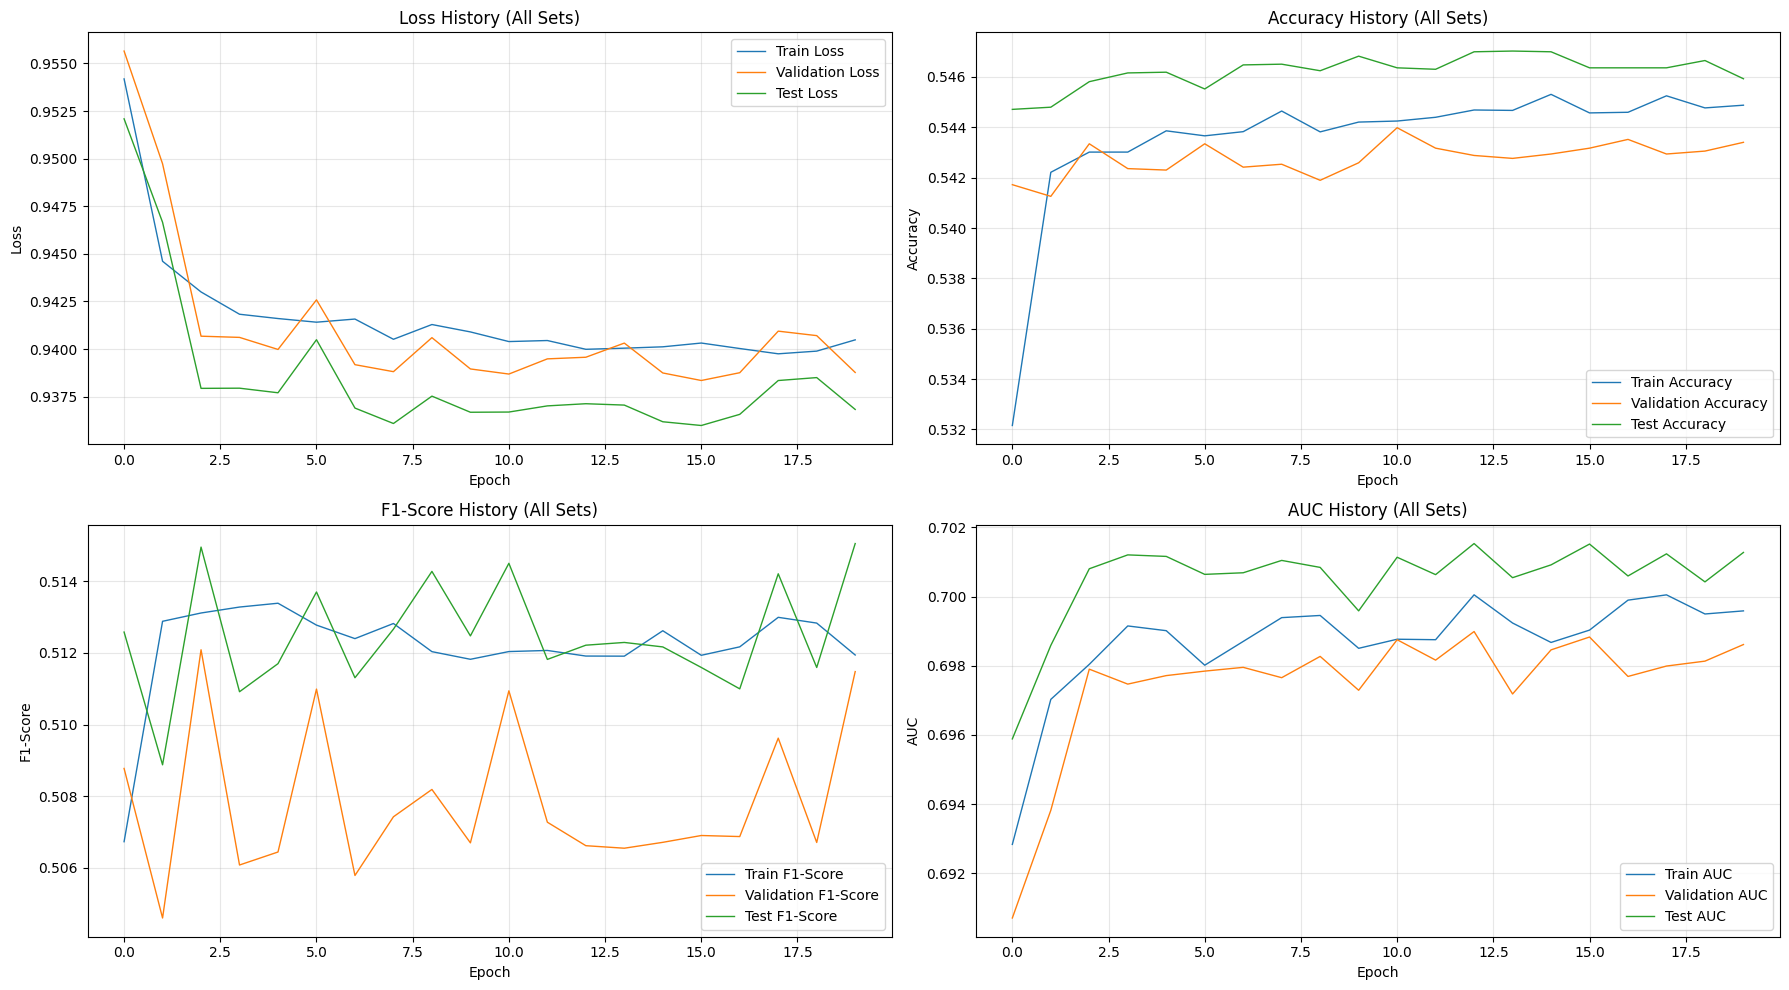


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

Intermediate       0.65      0.62      0.64     11514
  Non-Spiral       0.49      0.21      0.29     11515
      Spiral       0.50      0.81      0.62     11514

    accuracy                           0.55     34543
   macro avg       0.55      0.55      0.52     34543
weighted avg       0.55      0.55      0.52     34543



<Figure size 800x600 with 0 Axes>

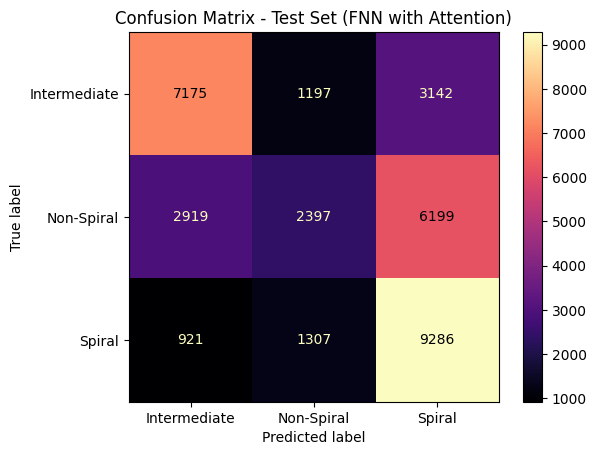


Shape X_test_lda: (34543, 2)
Shape y_test_array: (34543,)
Shape y_pred_array: (34543,)


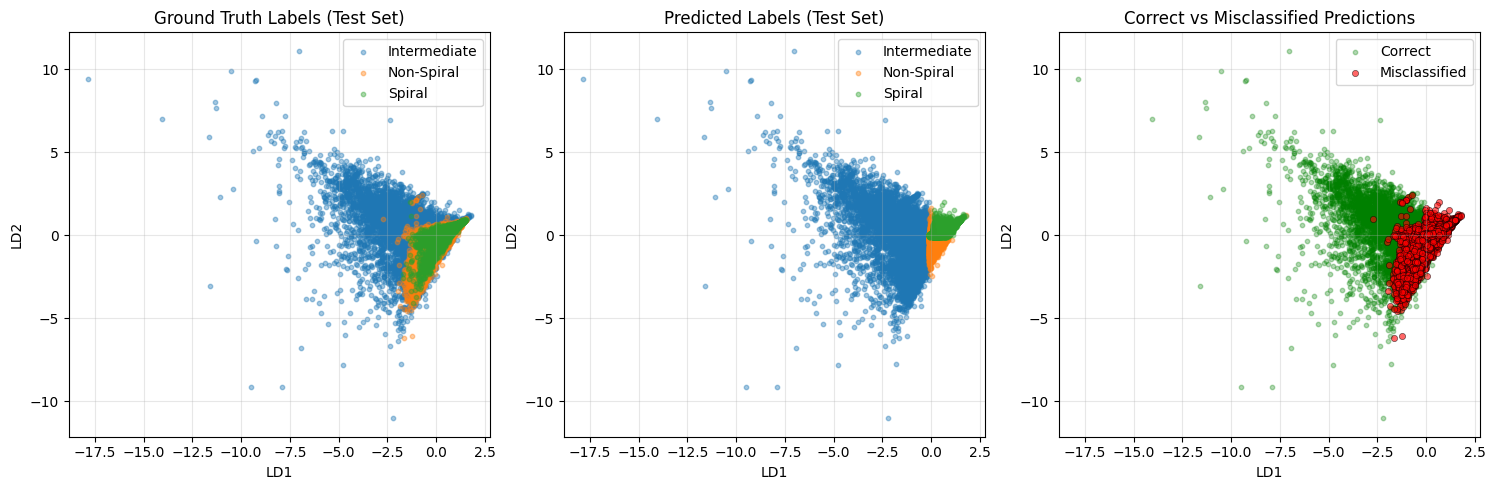

STATISTIK DETAIL
Train Loss         : 0.9405
Validation Loss    : 0.9388
Test Loss          : 0.9368
Train Accuracy     : 0.5449 (54.49%)
Train F1-Score     : 0.5119 (51.19%)
Validation Accuracy: 0.5434 (54.34%)
Validation F1-Score: 0.5115 (51.15%)
Best Validation F1 : 0.5121 (51.21%) at epoch 3
Test Accuracy      : 0.5459 (54.59%)
Test F1-Score      : 0.5150 (51.50%)
Test Precision     : 0.5463 (54.63%)
Test Recall        : 0.5459 (54.59%)


In [ ]:
# Preparation data
# Choose one of parameter arrays to use
batch_size = 32
# batch_size_list = [32, 64, 128, 256]
learning_rate = 0.005
# learning_rate_list = [0.005, 0.01, 0.05, 0.1]
alpha_list = [1, 1.5, 0.5, 0.1]
# alpha = 1
test_acc_results = []
test_auc_results = []
for alpha in alpha_list:
    class LDAFuzzyMembershipMuSigma:
        def __init__(self, X):
            self.X = X
            self.n_features = X.shape[1]
            self.params = []
            self._build_membership()

        def _build_membership(self):
            for i in range(self.n_features):
                xi = self.X[:, i]

                xmin = np.min(xi)
                xmax = np.max(xi)
                mu = np.mean(xi)
                sigma = np.std(xi)

                feature_params = {
                    "low":    [xmin, xmin, mu - alpha*sigma, mu],
                    "medium": [mu - alpha*sigma, mu, mu, mu + alpha*sigma],
                    "high":   [mu, mu + alpha*sigma, xmax, xmax]
                }

                self.params.append(feature_params)

        def trapezoidal(self, x, a, b, c, d):
            return np.maximum(
                np.minimum(
                    np.minimum((x - a) / (b - a + 1e-8), 1),
                    np.minimum((d - x) / (d - c + 1e-8), 1)
                ),
                0
            )

        def compute_membership(self, X_input):
            memberships = []

            for i in range(self.n_features):
                xi = X_input[:, i]
                p = self.params[i]

                low = self.trapezoidal(xi, *p["low"])
                med = self.trapezoidal(xi, *p["medium"])
                high = self.trapezoidal(xi, *p["high"])

                memberships.append(np.stack([low, med, high], axis=1))

            return np.concatenate(memberships, axis=1)

    fuzzy = LDAFuzzyMembershipMuSigma(X_lda)
    X_fuzzy = fuzzy.compute_membership(X_lda)

# Split data 7-1-2
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_fuzzy, y_final, test_size=0.3, random_state=209, stratify=y_final
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.667, random_state=209, stratify=y_temp
    )

    print(f"Train set      : {X_train.shape[0]} samples ({X_train.shape[0]/len(X_fuzzy)*100:.1f}%)")
    print(f"Validation set : {X_val.shape[0]} samples ({X_val.shape[0]/len(X_fuzzy)*100:.1f}%)")
    print(f"Test set       : {X_test.shape[0]} samples ({X_test.shape[0]/len(X_fuzzy)*100:.1f}%)")
    print(f"Total          : {len(X_fuzzy)} samples")
    print(f"Input features : {X_fuzzy.shape[1]}")

# Simpan indeks untuk plotting nanti
    train_indices = y_train.index
    val_indices = y_val.index
    test_indices = y_test.index

    print(f"\nIndices - Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

# Konversi ke tensor
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train.values, dtype=torch.long)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val.values, dtype=torch.long)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test.values, dtype=torch.long)

# DataLoader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define FNN with Attention
    class FNNWithAttention(nn.Module):
        def __init__(self, input_dim, num_classes):
            super(FNNWithAttention, self).__init__()
        
        # Fully connected layers
            self.fc1 = nn.Linear(input_dim, 64)
            self.bn1 = nn.BatchNorm1d(64)
            self.fc2 = nn.Linear(64, 32)
            self.bn2 = nn.BatchNorm1d(32)
            self.fc3 = nn.Linear(32, 16)
            self.bn3 = nn.BatchNorm1d(16)
        
        # Attention mechanism
            self.attention = nn.Sequential(
                nn.Linear(16, 8),
                nn.Tanh(),
                nn.Linear(8, 1)
            )
        
        # Output layer
            self.fc_out = nn.Linear(16, num_classes)
        
        # Regularization
            self.dropout = nn.Dropout(0.3)
        
        def forward(self, x):
        # Hidden layers
            x = F.relu(self.bn1(self.fc1(x)))
            x = self.dropout(x)
            x = F.relu(self.bn2(self.fc2(x)))
            x = self.dropout(x)
            x = F.relu(self.bn3(self.fc3(x)))
        
        # Attention weights
            attn_weights = self.attention(x)  # (batch_size, 1)
            attn_weights = F.softmax(attn_weights, dim=0)  # Normalize across batch
        
        # Apply attention (weighted features)
            x_attended = x * attn_weights
        
        # Output
            out = self.fc_out(x_attended)
            return out
  
# Initialization
    model = FNNWithAttention(input_dim=X_fuzzy.shape[1], num_classes=3)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)

# Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer, T_0=10, T_mult=2, eta_min=1e-5
            )

    print("\n" + "=" * 60)
    print("MODEL ARCHITECTURE")
    print("=" * 60)
    print(model)

# Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

# Training Loop with Validation
    num_epochs = 20
    train_losses = []
    val_losses = []
    test_losses = []  # Untuk menyimpan test loss per epoch
    train_accs = []
    val_accs = []
    train_f1_scores = []
    val_f1_scores = []
    learning_rates = []
    train_aucs = []
    val_aucs = []
    test_aucs = []

# Untuk evaluasi test per epoch
    test_accs_per_epoch = []
    test_aucs_per_epoch = []
    test_f1_scores_per_epoch = []
    test_precision_per_epoch = []
    test_recall_per_epoch = []

    best_val_f1 = 0.0
    best_epoch = 0
    best_model_state = None
    patience_counter = 0
    early_stop_patience = 30

    print("\n" + "=" * 60)
    print("TRAINING PROGRESS")
    print("=" * 60)

    for epoch in range(num_epochs):
    # Training Phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        all_train_preds = []
        all_train_labels = []
        all_train_probs = []
    
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
            all_train_preds.extend(predicted.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())
            probs = F.softmax(outputs, dim=1)
            all_train_probs.extend(probs.detach().cpu().numpy())   
    
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        train_f1 = f1_score(all_train_labels, all_train_preds, average='weighted')
        train_auc = roc_auc_score(all_train_labels, all_train_probs, multi_class='ovr', average='weighted')
    
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        train_f1_scores.append(train_f1)
        train_aucs.append(train_auc)
    
    # Validation Phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_val_preds = []
        all_val_labels = []
        all_val_probs = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())
                probs = F.softmax(outputs, dim=1)
                all_val_probs.extend(probs.detach().cpu().numpy())
    
        val_loss = val_loss / len(val_loader)
        val_acc = correct / total
        val_f1 = f1_score(all_val_labels, all_val_preds, average='weighted')
        val_auc = roc_auc_score(all_val_labels, all_val_probs, multi_class='ovr', average='weighted')
        
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_f1_scores.append(val_f1)
        val_aucs.append(val_auc)

    # Test phase (per epoch)
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        all_test_preds = []
        all_test_labels = []
        all_test_probs = []
    
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
                all_test_preds.extend(predicted.cpu().numpy())
                all_test_labels.extend(labels.cpu().numpy())
                probs = F.softmax(outputs, dim=1)
                all_test_probs.extend(probs.detach().cpu().numpy())
    
        test_loss = test_loss / len(test_loader)
        test_acc = test_correct / test_total
        test_f1 = f1_score(all_test_labels, all_test_preds, average='weighted')
        test_precision = precision_score(all_test_labels, all_test_preds, average='weighted', zero_division=0)
        test_recall = recall_score(all_test_labels, all_test_preds, average='weighted', zero_division=0)
        test_auc = roc_auc_score(all_test_labels, all_test_probs, multi_class='ovr', average='weighted')
    
        test_losses.append(test_loss)
        test_accs_per_epoch.append(test_acc)
        test_acc_results.append(test_acc)
        test_f1_scores_per_epoch.append(test_f1)
        test_precision_per_epoch.append(test_precision)
        test_recall_per_epoch.append(test_recall)
        test_aucs_per_epoch.append(test_auc)
        test_auc_results.append(test_auc)

    # Record learning rate
        current_lr = optimizer.param_groups[0]['lr']
        learning_rates.append(current_lr)
      
    # Learning rate scheduling
        scheduler.step(val_loss)
    
    # Save best model based on F1-score
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
    
    # Early stopping
        if patience_counter >= early_stop_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
    
    # Print progress
        if (epoch + 1) % 1 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}, Train AUC: {train_auc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, Val AUC: {val_auc:.4f} | "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}, Test AUC: {test_auc:.4f} | "
            f"LR: {current_lr:.2e}")

    print(f"\nTraining complete! Best validation F1-score: {best_val_f1:.4f} ({best_val_f1*100:.2f}%) at epoch {best_epoch+1}")

# Load best model
    model.load_state_dict(best_model_state)

# Plot metrics history
    plt.figure(figsize=(18, 10))

# Plot loss
    plt.subplot(2, 2, 1)
    plt.plot(train_losses, label='Train Loss', linewidth=1)
    plt.plot(val_losses, label='Validation Loss', linewidth=1)
    plt.plot(test_losses, label='Test Loss', linewidth=1)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss History (All Sets)')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot accuracy
    plt.subplot(2, 2, 2)
    plt.plot(train_accs, label='Train Accuracy', linewidth=1)
    plt.plot(val_accs, label='Validation Accuracy', linewidth=1)
    plt.plot(test_accs_per_epoch, label='Test Accuracy', linewidth=1)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy History (All Sets)')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot F1-score
    plt.subplot(2, 2, 3)
    plt.plot(train_f1_scores, label='Train F1-Score', linewidth=1)
    plt.plot(val_f1_scores, label='Validation F1-Score', linewidth=1)
    plt.plot(test_f1_scores_per_epoch, label='Test F1-Score', linewidth=1)
    plt.xlabel('Epoch')
    plt.ylabel('F1-Score')
    plt.title('F1-Score History (All Sets)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 4)
    plt.plot(train_aucs, label='Train AUC', linewidth=1)
    plt.plot(val_aucs, label='Validation AUC', linewidth=1)
    plt.plot(test_aucs_per_epoch, label='Test AUC', linewidth=1)
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.title('AUC History (All Sets)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Evaluation
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

# Classification report
    print("\n" + "=" * 60)
    print("CLASSIFICATION REPORT - TEST SET")
    print("=" * 60)
    print(classification_report(all_labels, all_preds, 
                              target_names=['Intermediate', 'Non-Spiral', 'Spiral']))

# Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                display_labels=['Intermediate', 'Non-Spiral', 'Spiral'])

    plt.figure(figsize=(8, 6))
    disp.plot(cmap='magma', values_format='d')
    plt.title('Confusion Matrix - Test Set (FNN with Attention)')
    plt.grid(False)
    plt.show()

# Prediction plot
    X_test_lda = X_lda[test_indices]
    y_test_array = y_test.values
    y_pred_array = np.array(all_preds)

    print(f"\nShape X_test_lda: {X_test_lda.shape}")
    print(f"Shape y_test_array: {y_test_array.shape}")
    print(f"Shape y_pred_array: {y_pred_array.shape}")

    plt.figure(figsize=(15, 5))

# Plot 1: Ground Truth
    plt.subplot(1, 3, 1)
    colors = ['red', 'blue', 'green']
    labels_map = ['Intermediate', 'Non-Spiral', 'Spiral']
    for label in range(3):
        mask = y_test_array == label
        plt.scatter(
            X_test_lda[mask, 0],
            X_test_lda[mask, 1],
        #c=colors[label],
            label=labels_map[label],
            alpha=0.4,
            s=10
        )
    plt.xlabel('LD1')
    plt.ylabel('LD2')
    plt.title('Ground Truth Labels (Test Set)')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot 2: Predictions
    plt.subplot(1, 3, 2)
    for label in range(3):
        mask = y_pred_array == label
        plt.scatter(
            X_test_lda[mask, 0],
            X_test_lda[mask, 1],
        #c=colors[label],
            label=labels_map[label],
            alpha=0.4,
            s=10
        )
    plt.xlabel('LD1')
    plt.ylabel('LD2')
    plt.title('Predicted Labels (Test Set)')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot 3: Correct vs Misclassified
    plt.subplot(1, 3, 3)
    misclassified_mask = y_pred_array != y_test_array
    plt.scatter(
        X_test_lda[~misclassified_mask, 0],
        X_test_lda[~misclassified_mask, 1],
        c='green', label='Correct', alpha=0.3, s=10
    )
    plt.scatter(
        X_test_lda[misclassified_mask, 0],
        X_test_lda[misclassified_mask, 1],
        c='red', label='Misclassified', alpha=0.6, s=20, edgecolors='black', linewidth=0.5
    )
    plt.xlabel('LD1')
    plt.ylabel('LD2')
    plt.title('Correct vs Misclassified Predictions')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Results
    print("=" * 60)
    print("Results")
    print("=" * 60)
    print(f"Train Loss         : {train_losses[-1]:.4f}")
    print(f"Validation Loss    : {val_losses[-1]:.4f}")
    print(f"Test Loss          : {test_losses[-1]:.4f}")
    print(f"Train Accuracy     : {train_accs[-1]:.4f} ({train_accs[-1]*100:.2f}%)")
    print(f"Train F1-Score     : {train_f1_scores[-1]:.4f} ({train_f1_scores[-1]*100:.2f}%)")
    print(f"Validation Accuracy: {val_accs[-1]:.4f} ({val_accs[-1]*100:.2f}%)")
    print(f"Validation F1-Score: {val_f1_scores[-1]:.4f} ({val_f1_scores[-1]*100:.2f}%)")
    print(f"Best Validation F1 : {best_val_f1:.4f} ({best_val_f1*100:.2f}%) at epoch {best_epoch+1}")
    print(f"Test Accuracy      : {accuracy_score(all_labels, all_preds):.4f} ({accuracy_score(all_labels, all_preds)*100:.2f}%)")
    print(f"Test F1-Score      : {f1_score(all_labels, all_preds, average='weighted'):.4f} ({f1_score(all_labels, all_preds, average='weighted')*100:.2f}%)")
    print(f"Test Precision     : {precision_score(all_labels, all_preds, average='weighted'):.4f} ({precision_score(all_labels, all_preds, average='weighted')*100:.2f}%)")
    print(f"Test Recall        : {recall_score(all_labels, all_preds, average='weighted'):.4f} ({recall_score(all_labels, all_preds, average='weighted')*100:.2f}%)")

### Plot Sensitivity Analysis

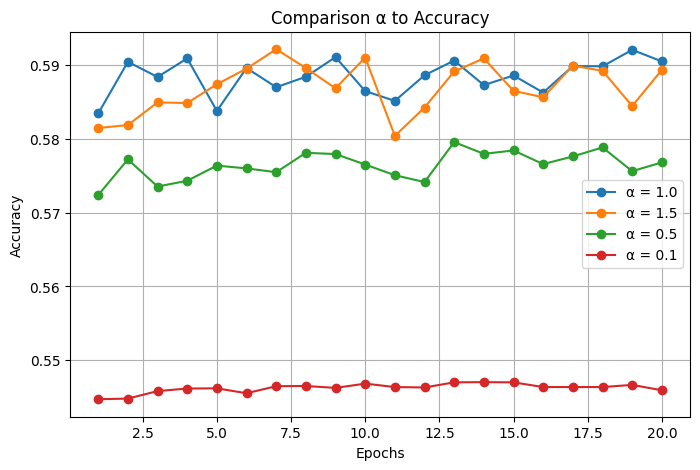

In [ ]:
epochs = np.arange(1, num_epochs + 1)
plt.figure(figsize=(8,5))
plt.plot(epochs, test_acc_results[0:int(4*num_epochs*(1/4))], linewidth=1.5, marker='o', label="α = 1.0")
plt.plot(epochs, test_acc_results[int(4*num_epochs*(1/4)):int(4*num_epochs*(2/4))], linewidth=1.5, marker='o', label="α = 1.5")
plt.plot(epochs, test_acc_results[int(4*num_epochs*(2/4)):int(4*num_epochs*(3/4))], linewidth=1.5, marker='o', label="α = 0.5")
plt.plot(epochs, test_acc_results[int(4*num_epochs*(3/4)):], linewidth=1.5, marker='o', label="α = 0.1")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Comparison α to Accuracy")
plt.grid(True)
plt.legend()
plt.show()

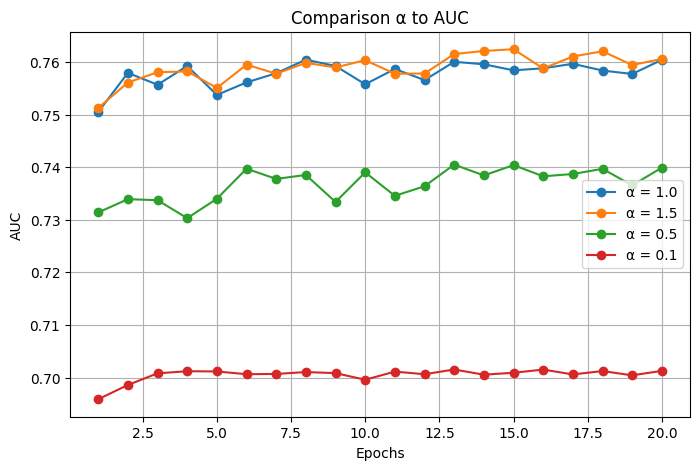

In [7]:
plt.figure(figsize=(8,5))
plt.plot(epochs, test_auc_results[0:int(4*num_epochs*(1/4))], linewidth=1.5, marker='o', label="α = 1.0")
plt.plot(epochs, test_auc_results[int(4*num_epochs*(1/4)):int(4*num_epochs*(2/4))], linewidth=1.5, marker='o', label="α = 1.5")
plt.plot(epochs, test_auc_results[int(4*num_epochs*(2/4)):int(4*num_epochs*(3/4))], linewidth=1.5, marker='o', label="α = 0.5")
plt.plot(epochs, test_auc_results[int(4*num_epochs*(3/4)):], linewidth=1.5, marker='o', label="α = 0.1")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.title("Comparison α to AUC")
plt.grid(True)
plt.legend()
plt.show()